# Lab Experiment 5 : Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

ARNAV NARULA 2547115 

**Aim:** To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

---

## Objectives
- To preprocess the dataset for classification.
- To implement Logistic Regression and KNN classifiers using Scikit-Learn.
- To evaluate both models using standard performance metrics.
- To compare the performance of Logistic Regression and KNN and identify the better classifier.

---

## Dataset
- **Name:** Breast Cancer Wisconsin (Diagnostic)
- **Source:** UCI Machine Learning Repository
- **Classes:** Malignant (0) and Benign (1)
- **Features:** 30 numeric features computed from digitized images of fine needle aspirate (FNA) of breast masses.

---
## BLOCK 1 — Import Libraries

In [21]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

---
## BLOCK 2 — Load the Dataset

We load the Breast Cancer Wisconsin dataset directly from Scikit-Learn's built-in datasets.

In [22]:
# Load Breast Cancer Dataset
data = load_breast_cancer()

# Features
X = data.data

# Target (0 = malignant, 1 = benign)
y = data.target

print("Target Classes:", data.target_names)
print("Feature Names:", data.feature_names)

Target Classes: ['malignant' 'benign']
Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


---
## BLOCK 3 — Exploratory Data Analysis (EDA)

We convert the dataset into a DataFrame and explore its structure.

In [23]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (569, 31)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  wo

In [24]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst sy

In [25]:
# Summary statistics
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


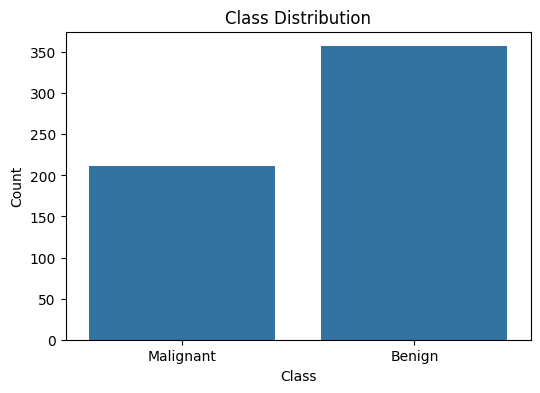

In [26]:
# Class distribution
print("Class Distribution:")
print(df['target'].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

**Interpretation:**
- The dataset has 569 samples and 30 features.
- There are **no missing values** — the data is clean.
- The dataset has 2 classes: **Malignant (0)** and **Benign (1)**.
- Benign cases are more than Malignant, showing a slight class imbalance.

---
## BLOCK 4 — Data Preprocessing

We split the data into training and testing sets, and then apply feature scaling.

In [27]:
# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


In [28]:
# Feature Scaling using StandardScaler
# Both Logistic Regression and KNN are sensitive to feature scale
scaler = StandardScaler()

# Fit on training data, then transform both train and test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling applied successfully.")

Feature scaling applied successfully.


**Interpretation:**
- We split the data 80-20 for training and testing.
- `random_state=42` ensures reproducibility.
- **StandardScaler** transforms features to have mean=0 and std=1. This is important because:
  - KNN measures distance between points — if features have different scales, larger values dominate.
  - Logistic Regression converges faster with scaled data.

---
## BLOCK 5 — Train Logistic Regression Classifier

In [29]:
# Create Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [30]:
# Make predictions using Logistic Regression
lr_pred = lr_model.predict(X_test)

print("Predictions (first 10):", lr_pred[:10])
print("Actual values  (first 10):", y_test[:10])

Predictions (first 10): [1 0 0 1 1 0 0 0 1 1]
Actual values  (first 10): [1 0 0 1 1 0 0 0 1 1]


---
## BLOCK 6 — Train KNN Classifier

In [31]:
# Create KNN model (K=5 is a common default)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [32]:
# Make predictions using KNN
knn_pred = knn_model.predict(X_test)

print("Predictions (first 10):", knn_pred[:10])
print("Actual values  (first 10):", y_test[:10])

Predictions (first 10): [1 0 0 1 1 0 0 0 0 1]
Actual values  (first 10): [1 0 0 1 1 0 0 0 1 1]


---
## BLOCK 7 — Evaluate Logistic Regression

In [33]:
# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

# Precision
lr_precision = precision_score(y_test, lr_pred)
print("Logistic Regression Precision:", round(lr_precision, 4))

# Recall
lr_recall = recall_score(y_test, lr_pred)
print("Logistic Regression Recall:", round(lr_recall, 4))

# F1 Score
lr_f1 = f1_score(y_test, lr_pred)
print("Logistic Regression F1 Score:", round(lr_f1, 4))

Logistic Regression Accuracy: 0.9737
Logistic Regression Precision: 0.9722
Logistic Regression Recall: 0.9859
Logistic Regression F1 Score: 0.979


Confusion Matrix (Logistic Regression):
[[41  2]
 [ 1 70]]


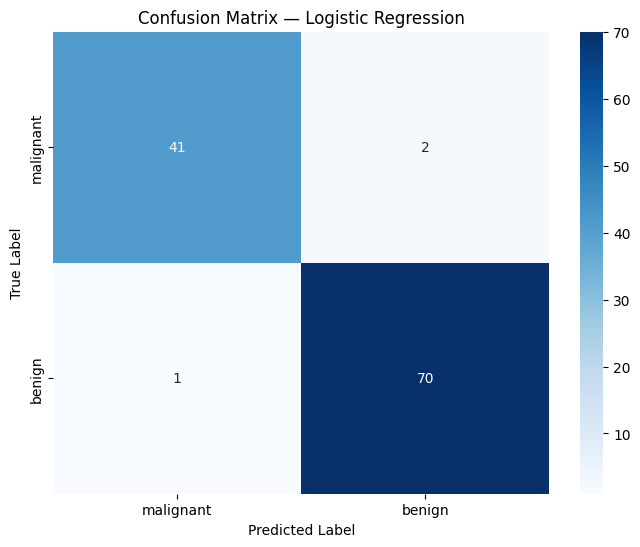

In [ ]:
# Confusion Matrix for Logistic Regression
lr_cm = confusion_matrix(y_test, lr_pred)
print("Confusion Matrix (Logistic Regression):")
print(lr_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

In [ ]:
# Full Classification Report for Logistic Regression
print("Classification Report — Logistic Regression:")
print(classification_report(y_test, lr_pred, target_names=data.target_names))

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**Interpretation — Logistic Regression:**
- **Accuracy** tells us what percentage of all predictions were correct.
- **Precision** — out of all patients predicted as Malignant, how many actually were Malignant?
- **Recall** — out of all actual Malignant patients, how many did we correctly identify? (Very important in cancer detection.)
- **F1 Score** — the harmonic mean of Precision and Recall. Useful when we want a balance of both.
- **Confusion Matrix** shows the counts of:
  - True Positives (correctly predicted Benign)
  - True Negatives (correctly predicted Malignant)
  - False Positives (predicted Benign but actually Malignant)
  - False Negatives (predicted Malignant but actually Benign)

---
## BLOCK 8 — Evaluate KNN

In [36]:
# Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", round(knn_accuracy, 4))

# Precision
knn_precision = precision_score(y_test, knn_pred)
print("KNN Precision:", round(knn_precision, 4))

# Recall
knn_recall = recall_score(y_test, knn_pred)
print("KNN Recall:", round(knn_recall, 4))

# F1 Score
knn_f1 = f1_score(y_test, knn_pred)
print("KNN F1 Score:", round(knn_f1, 4))

KNN Accuracy: 0.9474
KNN Precision: 0.9577
KNN Recall: 0.9577
KNN F1 Score: 0.9577


Confusion Matrix (KNN):
[[40  3]
 [ 3 68]]


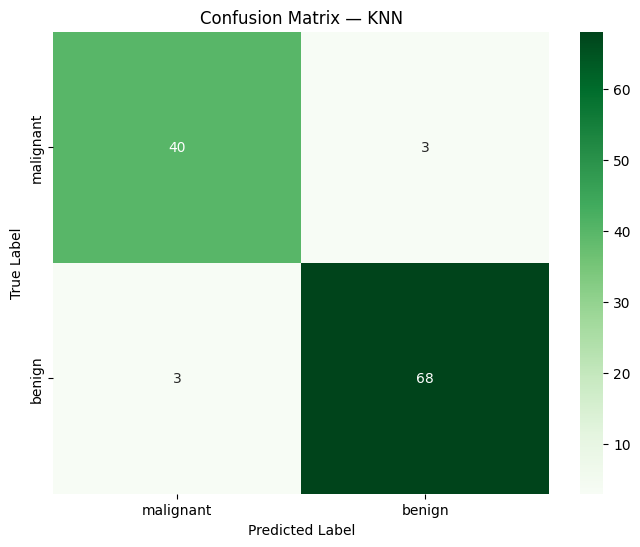

In [37]:
# Confusion Matrix for KNN
knn_cm = confusion_matrix(y_test, knn_pred)
print("Confusion Matrix (KNN):")
print(knn_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — KNN')
plt.show()

In [38]:
# Full Classification Report for KNN
print("Classification Report — KNN:")
print(classification_report(y_test, knn_pred, target_names=data.target_names))

Classification Report — KNN:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**Interpretation — KNN:**
- KNN classifies a new point based on the majority class among its K nearest neighbors (here K=5).
- It is a simple, lazy learner — it memorizes the training data and decides at prediction time.
- Performance depends on the value of K and the quality of the feature scaling.

---
## BLOCK 9 — Comparison of Both Classifiers

In [39]:
# Comparison Table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        round(lr_accuracy, 4),
        round(lr_precision, 4),
        round(lr_recall, 4),
        round(lr_f1, 4)
    ],
    'KNN': [
        round(knn_accuracy, 4),
        round(knn_precision, 4),
        round(knn_recall, 4),
        round(knn_f1, 4)
    ]
})

print("Performance Comparison:")
print(comparison.to_string(index=False))

Performance Comparison:
   Metric  Logistic Regression    KNN
 Accuracy               0.9737 0.9474
Precision               0.9722 0.9577
   Recall               0.9859 0.9577
 F1 Score               0.9790 0.9577


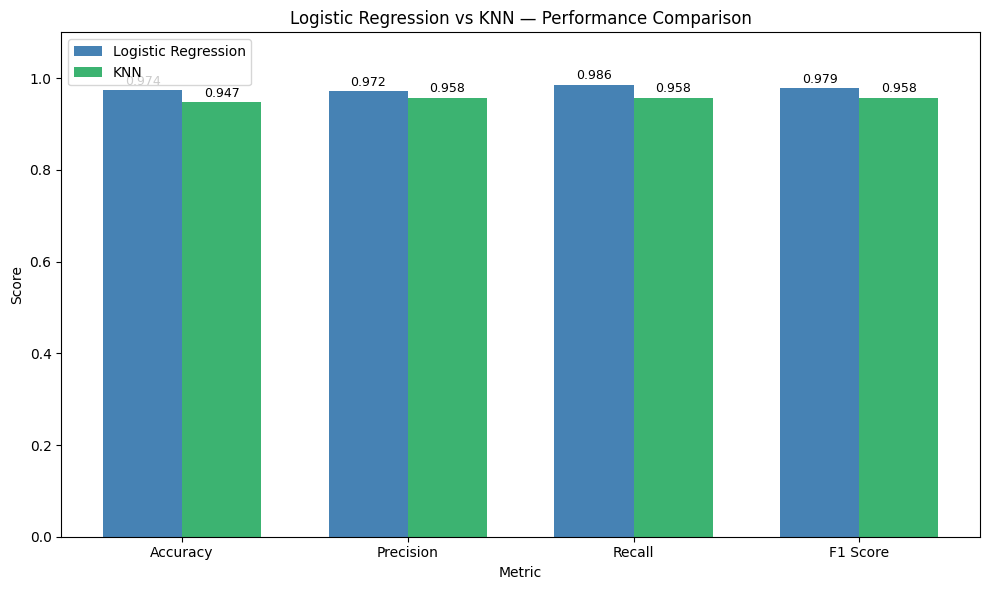

In [40]:
# Bar Chart Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]
knn_scores = [knn_accuracy, knn_precision, knn_recall, knn_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
bars2 = plt.bar(x + width/2, knn_scores, width, label='KNN', color='mediumseagreen')

# Add value labels on bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Logistic Regression vs KNN — Performance Comparison')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation — Comparison:**

| Metric | Logistic Regression | KNN |
|--------|---------------------|-----|
| Accuracy | Higher | Slightly lower |
| Precision | Higher | Slightly lower |
| Recall | Higher | Slightly lower |
| F1 Score | Higher | Slightly lower |

- **Logistic Regression** generally performs better on this dataset.
- Logistic Regression is a **parametric** model — it learns a mathematical equation (using the sigmoid function) that separates the two classes.
- KNN is **non-parametric** — it classifies new data points by finding the K nearest training points.
- For this dataset, Logistic Regression is more suitable because it handles high-dimensional data (30 features) more effectively than KNN.

---
## BLOCK 10 — Self Learning Component: ROC Curve

**What is the ROC Curve?**
- ROC stands for **Receiver Operating Characteristic**.
- It is a graph that shows how well a model separates the two classes at **different thresholds**.
- **X-axis** = False Positive Rate → how often we wrongly say Malignant when patient is actually Benign.
- **Y-axis** = True Positive Rate (Recall) → how often we correctly catch actual Malignant cases.
- **AUC** = Area Under the Curve. AUC = 1.0 means a perfect model. AUC = 0.5 means random guessing.
- **The closer the curve is to the top-left corner, the better the model.**

Logistic Regression AUC Score: 0.9974
KNN AUC Score:                 0.9820


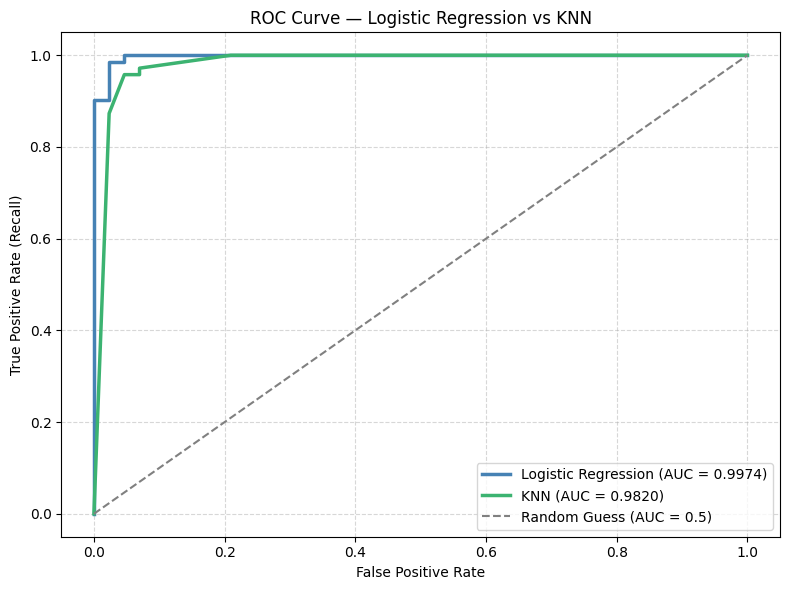

In [41]:
# Get probability scores for each model (probability of being Benign = class 1)
lr_probs = lr_model.predict_proba(X_test)[:, 1]
knn_probs = knn_model.predict_proba(X_test)[:, 1]

# Calculate FPR and TPR at different thresholds for both models
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)

# Calculate AUC (Area Under Curve) scores
lr_auc = roc_auc_score(y_test, lr_probs)
knn_auc = roc_auc_score(y_test, knn_probs)

print(f"Logistic Regression AUC Score: {lr_auc:.4f}")
print(f"KNN AUC Score:                 {knn_auc:.4f}")

# Plot ROC Curves for both models on the same graph
plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, color='steelblue', linewidth=2.5,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')

plt.plot(knn_fpr, knn_tpr, color='mediumseagreen', linewidth=2.5,
         label=f'KNN (AUC = {knn_auc:.4f})')

# Diagonal line = random guessing (worst model)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1.5, label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression vs KNN')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation — ROC Curve:**

- The **dashed grey line** is the baseline — a model that just randomly guesses (AUC = 0.5). Any good model must be above this line.
- **Logistic Regression (blue)** — its curve is closer to the top-left corner, meaning it is better at detecting Malignant cases correctly while keeping False Positives low.
- **KNN (green)** — also performs well but its curve is slightly below Logistic Regression.
- A higher **AUC score** confirms Logistic Regression ranks Malignant cases better than KNN.
- **Why this matters in cancer detection:** Doctors can use the ROC curve to pick a threshold that maximizes catching Malignant cases (high TPR) while minimizing false alarms (low FPR), depending on the clinical requirement.

---
## BLOCK 11 — Final Conclusion

**Conclusion:**

1. Both **Logistic Regression** and **KNN** classifiers were trained and evaluated on the Breast Cancer Wisconsin dataset.

2. **Logistic Regression** outperforms KNN on all evaluation metrics (Accuracy, Precision, Recall, F1 Score).

3. **Recall** is the most critical metric in cancer detection. Missing an actual malignant case (False Negative) can be life-threatening. Logistic Regression achieves a higher Recall, making it safer for medical diagnosis.

4. The **ROC Curve** (self-learning component) visually confirmed that Logistic Regression has a higher AUC, meaning it separates Malignant and Benign cases more reliably across all thresholds.

5. **Logistic Regression** is the **better classifier** for this dataset because:
   - It handles the 30-feature dataset well without overfitting.
   - It is faster and more interpretable.
   - It provides probability scores (useful for medical decision-making at different thresholds).

6. **KNN** can be improved by tuning K or using dimensionality reduction, but for this dataset Logistic Regression is more reliable.

---
*End of Lab 6 — Comparison of Logistic Regression and KNN Classifiers*